In [235]:
import pandas as pd
import numpy as np
import platform
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [236]:
os = platform.system()

# 한글이 깨지지 않는 폰트로 수정
if os == 'Windows':
    plt.rc('font', family= 'Malgun Gothic')
    
elif os == 'Darwin':
    plt.rc('font', family= 'AppleGothic')

elif os == 'Linux':
    plt.rc('font', family= 'NanumGothic')

else:
    print(f'{os} is not set')

In [237]:
df = pd.read_csv("../data/ai4i2020.csv")

In [238]:
df = df.rename(columns={
    "UDI": "고유번호",
    "Product ID": "제품ID",
    "Type": "제품등급",
    "Air temperature [K]": "주변온도_K",
    "Process temperature [K]": "공정온도_K",
    "Rotational speed [rpm]": "회전속도_rpm",
    "Torque [Nm]": "토크_Nm",
    "Tool wear [min]": "공구마모_분",
    "Machine failure": "기계고장",
    "TWF": "공구마모고장",
    "HDF": "열방출고장",
    "PWF": "동력고장",
    "OSF": "과부하고장",
    "RNF": "무작위고장"
})

In [239]:
df.head()

,고유번호,제품ID,제품등급,주변온도_K,공정온도_K,회전속도_rpm,토크_Nm,공구마모_분,기계고장,공구마모고장,열방출고장,동력고장,과부하고장,무작위고장
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [240]:
df.describe()

,고유번호,주변온도_K,공정온도_K,회전속도_rpm,토크_Nm,공구마모_분,기계고장,공구마모고장,열방출고장,동력고장,과부하고장,무작위고장
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [241]:
len(df)

10000

In [242]:
df['기계고장'].value_counts(normalize=True)*100

기계고장
0    96.61
1     3.39
Name: proportion, dtype: float64

In [243]:
df['기계고장'].value_counts()

기계고장
0    9661
1     339
Name: count, dtype: int64

In [244]:
df['공구마모고장'].value_counts()

공구마모고장
0    9954
1      46
Name: count, dtype: int64

In [245]:
df['열방출고장'].value_counts()

열방출고장
0    9885
1     115
Name: count, dtype: int64

In [246]:
df['동력고장'].value_counts()

동력고장
0    9905
1      95
Name: count, dtype: int64

In [247]:
df['과부하고장'].value_counts()

과부하고장
0    9902
1      98
Name: count, dtype: int64

In [248]:
df['무작위고장'].value_counts()

무작위고장
0    9981
1      19
Name: count, dtype: int64

In [249]:
fails = ['공구마모고장','열방출고장','동력고장','과부하고장','무작위고장']

In [250]:
df_fail = df.drop(columns=(fails+['고유번호']))

In [251]:
df_fail = df_fail[[c for c in df_fail if c != '기계고장'] + ['기계고장']]

c:\Users\user\miniconda3\envs\fristenv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
c:\Users\user\miniconda3\envs\fristenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


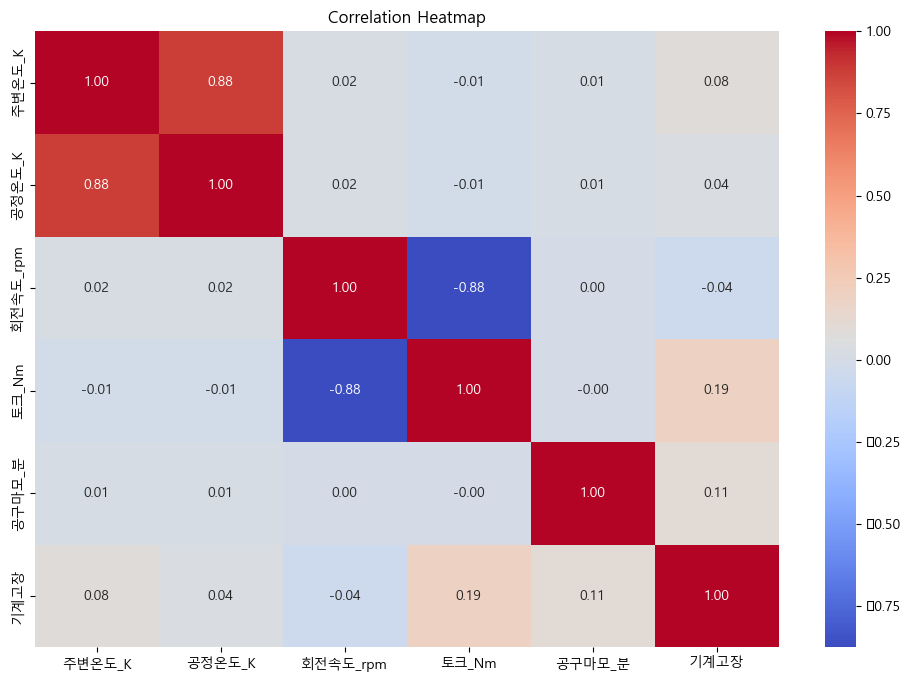

In [252]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

corr = df_fail.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

회전속도_지수가 0에 가까움. 이거는 필요 없을 것 같음

In [253]:
import math
df_fail['마모'] = df_fail['토크_Nm']*df_fail['회전속도_rpm']*2*math.pi/60
scaler = MinMaxScaler()

df_fail[['마모_지수']] = np.exp(
    scaler.fit_transform(df_fail[['마모']])
)

In [254]:
df_fail['고사용'] = df_fail['토크_Nm'] * df_fail['회전속도_rpm']

c:\Users\user\miniconda3\envs\fristenv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
c:\Users\user\miniconda3\envs\fristenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


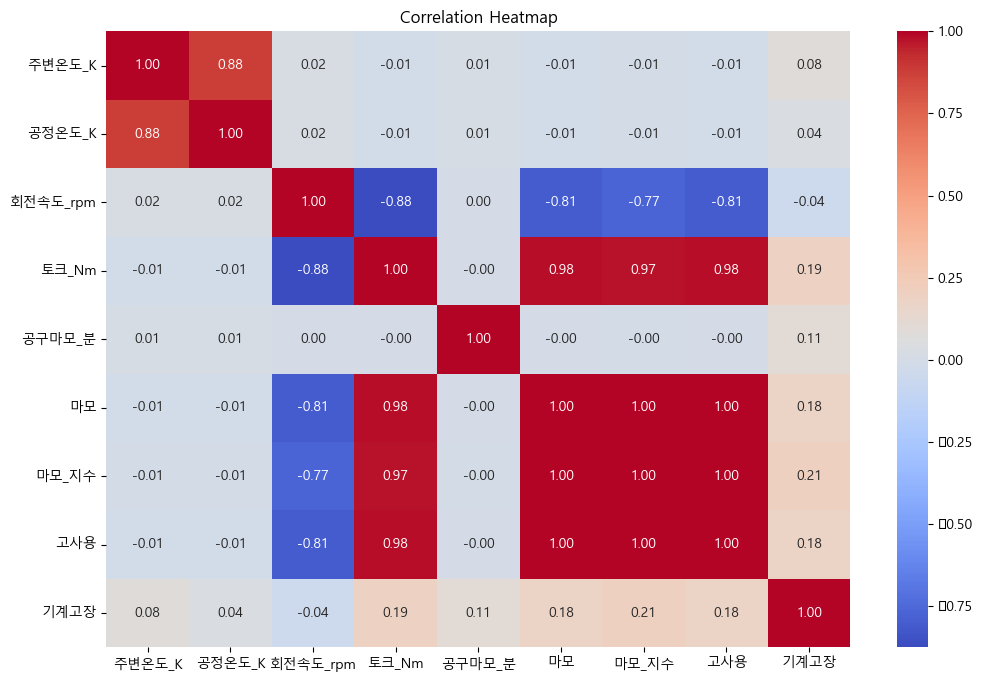

In [255]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

df_fail = df_fail[[c for c in df_fail if c != '기계고장'] + ['기계고장']]

corr = df_fail.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

# RPM별 고장 비율

RPM에 따라서 고장이 날 확률이 높다고 생각을 했습니다. 물론 RMP이 직접적인 원인이 아니겠지만, RPM이 올라감으로 인하여 생기는 여러가지 효과들로 그렇다고 생각을 해서 RPM별 고장 비율을 확인하기로 했습니다.

In [256]:
df_fail['회전속도_rpm'].describe()

count    10000.000000
mean      1538.776100
std        179.284096
min       1168.000000
25%       1423.000000
50%       1503.000000
75%       1612.000000
max       2886.000000
Name: 회전속도_rpm, dtype: float64

In [257]:
rpm_bins = [1100, 1300, 1400, 1500, 1600, 1700, 1900, 2200, 3000]

rpm_labels = [
    '1100~1300',
    '1300~1400',
    '1400~1500',
    '1500~1600',
    '1600~1700',
    '1700~1900',
    '1900~2200',
    '2200~3000'
]

df_fail['RPM_구간'] = pd.cut(
    df_fail['회전속도_rpm'],
    bins=rpm_bins,
    labels=rpm_labels,
    right=False
)

rpm_failure = df_fail.groupby('RPM_구간', observed=True).agg(
    전체수=('기계고장', 'count'),
    고장수=('기계고장', 'sum'),
    고장률=('기계고장', 'mean')
)

rpm_failure['고장률'] *= 100

rpm_failure

,전체수,고장수,고장률
RPM_구간,,,
1100~1300,211,49,23.222749
1300~1400,1636,187,11.430318
1400~1500,3052,42,1.376147
1500~1600,2378,12,0.504626
1600~1700,1376,9,0.654070
1700~1900,936,5,0.534188
1900~2200,315,4,1.269841
2200~3000,96,31,32.291667


RPM이 높으면 고장이 많이 날 것이라는 예측이 맞긴 했으나, RPM이 2200을 넘는 시점과 RPM이 1300보다 낮은 시점에서 더 고장이 잘 나는 것을 확인했습니다.

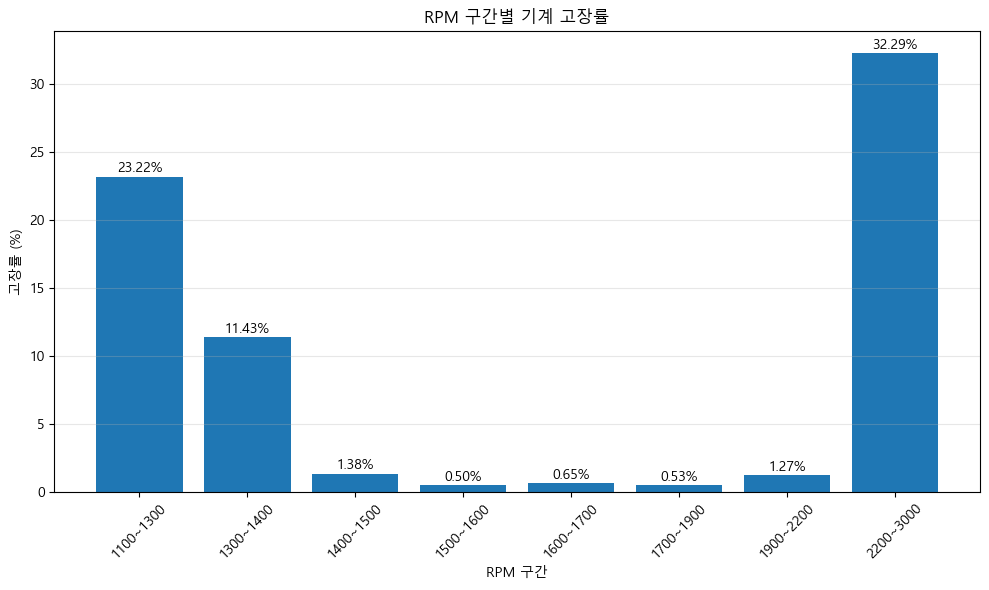

In [258]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    rpm_failure.index.astype(str),
    rpm_failure['고장률']
)

plt.xlabel('RPM 구간')
plt.ylabel('고장률 (%)')
plt.title('RPM 구간별 기계 고장률')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# 막대 위에 고장률 표시
for i, v in enumerate(rpm_failure['고장률']):
    plt.text(
        i, v + 0.3,
        f'{v:.2f}%',
        ha='center',
        fontsize=10
    )

plt.tight_layout()
plt.show()

이러면 RPM을 지수함수화 한다면, 뒷 부분은 잘 반영이 되겠지만, 앞 RPM이 낮은 부분은 반영이 되지 않아서 좋은 파생변수가 되지 않을 것이다. 그러면 어떻게 하면 좋을까? 위 그래프의 가장 윗 부분을 연결해보면 2차함수 그래프 처럼 나온다. 2차함수 그래프로 만들어보면 좋겠다.

In [259]:
df_fail['회전속도_파생2차'] = df_fail['회전속도_rpm']*df_fail['회전속도_rpm']

c:\Users\user\miniconda3\envs\fristenv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
c:\Users\user\miniconda3\envs\fristenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


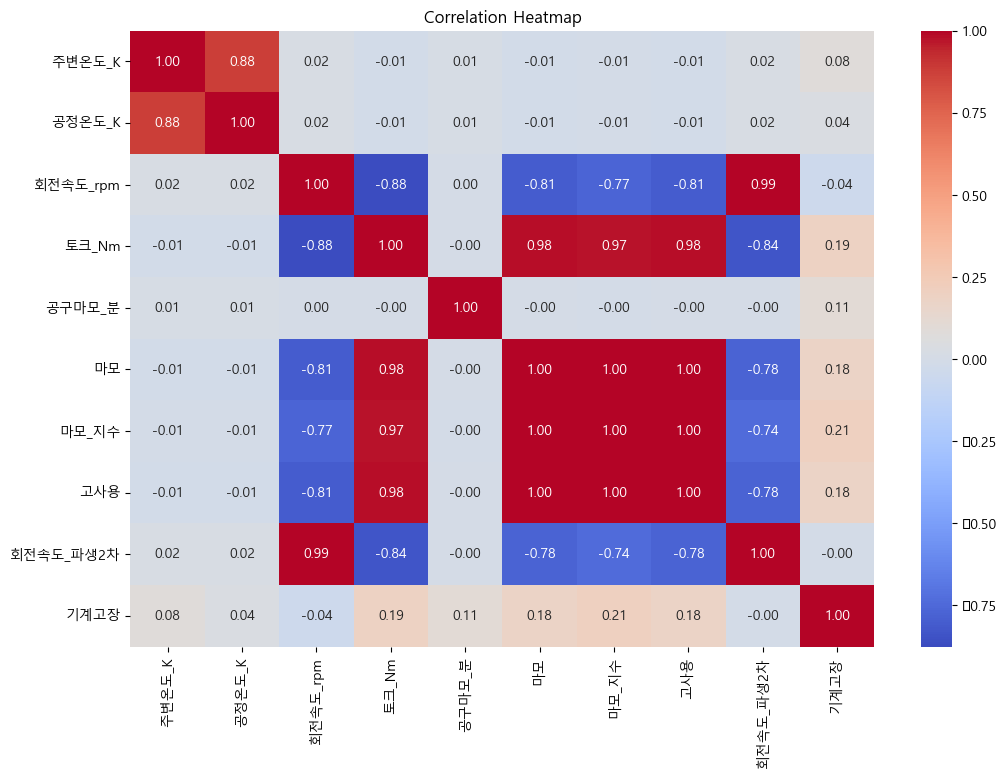

In [260]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

df_fail = df_fail[[c for c in df_fail if c != '기계고장'] + ['기계고장']]

corr = df_fail.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

에초에 RPM 자체가 큰 영역을 차지하지 않아서 이런 결과가 나온 것 같다. 1차로 만드는 파생 변수들을 상관계수가 높은 변수들로 만들기로 하자.

# 토크_Nm으로 파생변수를 만들어보자

In [261]:
df_fail['토크_Nm'].describe()

count    10000.000000
mean        39.986910
std          9.968934
min          3.800000
25%         33.200000
50%         40.100000
75%         46.800000
max         76.600000
Name: 토크_Nm, dtype: float64

In [262]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 토크 5 Nm 단위 구간
bins = np.arange(0, 81, 5)
labels = [f'{i}~{i+5}' for i in range(0, 80, 5)]

df_fail['토크_구간'] = pd.cut(
    df_fail['토크_Nm'],
    bins=bins,
    labels=labels,
    right=False
)

torque_failure = df_fail.groupby(
    '토크_구간',
    observed=True
).agg(
    전체수=('기계고장', 'count'),
    고장수=('기계고장', 'sum'),
    고장률=('기계고장', 'mean')
).reset_index()

torque_failure['고장률'] *= 100

torque_failure

,토크_구간,전체수,고장수,고장률
0,0~5,3,3,100.000000
1,5~10,8,8,100.000000
2,10~15,46,19,41.304348
3,15~20,171,4,2.339181
4,20~25,459,2,0.435730
5,25~30,889,7,0.787402
6,30~35,1466,6,0.409277
7,35~40,1898,13,0.684932
8,40~45,1934,13,0.672182
9,45~50,1553,53,3.412750


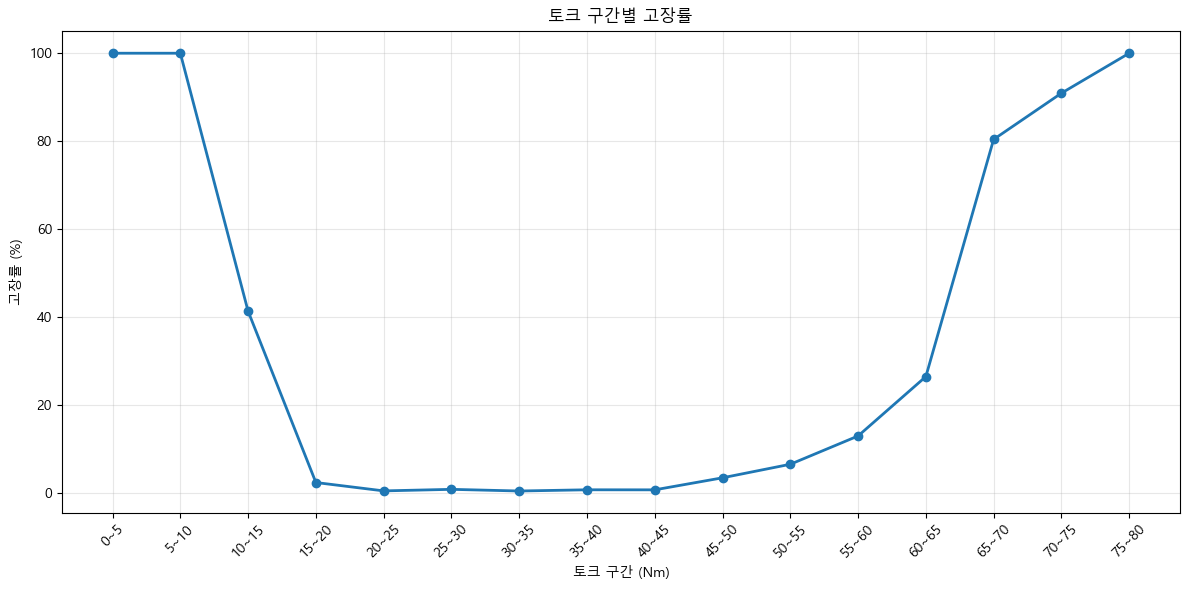

In [263]:
plt.figure(figsize=(12, 6))

plt.plot(
    torque_failure['토크_구간'],
    torque_failure['고장률'],
    marker='o',
    linewidth=2
)

plt.xlabel('토크 구간 (Nm)')
plt.ylabel('고장률 (%)')
plt.title('토크 구간별 고장률')

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

토그 역시 RPM하고 같다. 2차함수로 적용해보자!

In [264]:
df_fail['토크_2차'] = df_fail['토크_Nm']*df_fail['토크_Nm']

c:\Users\user\miniconda3\envs\fristenv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
c:\Users\user\miniconda3\envs\fristenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


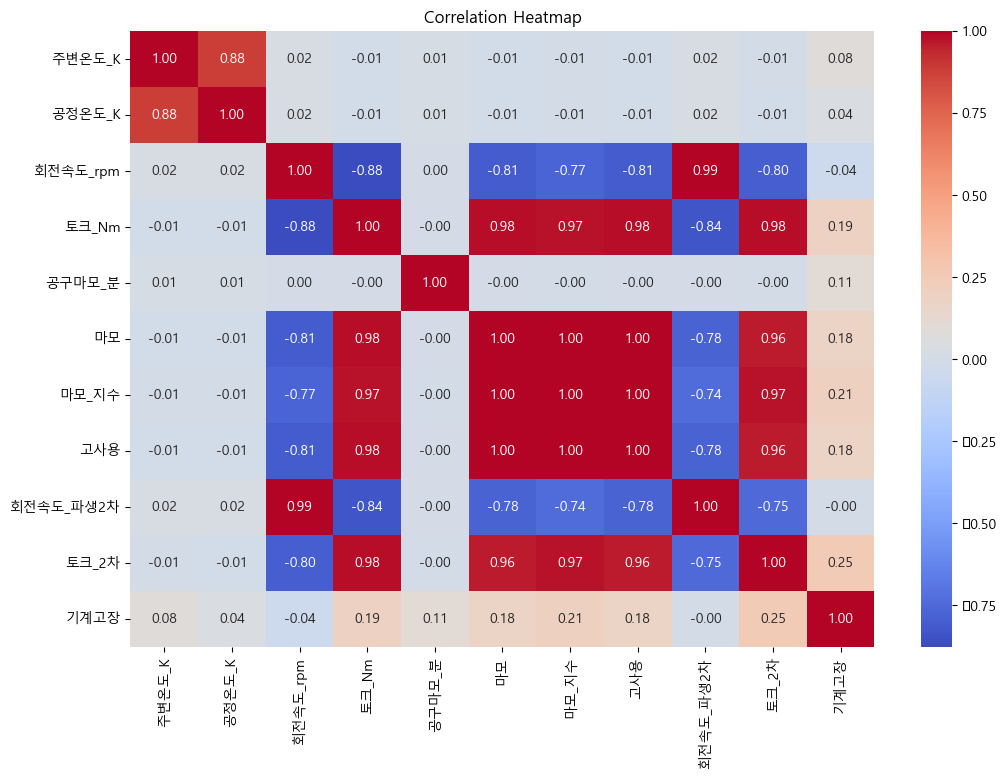

In [265]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

df_fail = df_fail[[c for c in df_fail if c != '기계고장'] + ['기계고장']]

corr = df_fail.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [267]:
df_fail['공구마모_분'].describe()

count    10000.000000
mean       107.951000
std         63.654147
min          0.000000
25%         53.000000
50%        108.000000
75%        162.000000
max        253.000000
Name: 공구마모_분, dtype: float64

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 토크 5 Nm 단위 구간
bins = np.arange(0, 81, 5)
labels = [f'{i}~{i+5}' for i in range(0, 80, 5)]

df_fail['공구마모_구간'] = pd.cut(
    df_fail['공구마모_분'],
    bins=bins,
    labels=labels,
    right=False
)

torque_failure = df_fail.groupby(
    '공구마모_구간',
    observed=True
).agg(
    전체수=('기계고장', 'count'),
    고장수=('기계고장', 'sum'),
    고장률=('기계고장', 'mean')
).reset_index()

torque_failure['고장률'] *= 100

torque_failure